In [281]:
import numpy as np
import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2025-01-26 15:50:21.009346: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df_ev = pd.read_csv("data/cleaned_chargingdata.csv")
df_weather = pd.read_csv("data/cleaned_weather_data.csv")

In [3]:
df_ev

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,chargingDuration
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,262.683333
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,401.250000
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,158.516667
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,78.783333
4,4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,257.483333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64987,65032,8670,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12-07:00,2019-07-01 18:37:18-07:00,2019-07-01 16:14:33-07:00,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,1346.0,85.350000
64988,65033,8671,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45-07:00,2019-07-01 17:39:48-07:00,2019-07-01 17:39:48-07:00,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,364.0,161.050000
64989,65034,8672,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21-07:00,2019-07-01 17:58:50-07:00,2019-07-01 17:58:50-07:00,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,2050.0,176.483333
64990,65035,8673,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44-07:00,2019-07-01 19:03:36-07:00,2019-07-01 19:03:36-07:00,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,1626.0,219.866667


In [4]:
df_ev[df_ev.id == '5ea3848df9af8b428bf97225']

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,chargingDuration
3756,3756,3756,5ea3848df9af8b428bf97225,2020-04-08 09:36:53-07:00,2020-04-08 20:43:29-07:00,2020-04-08 20:43:29-07:00,25.183,1_1_194_822_2020-04-08 16:36:53.316264,1,AG-1F12,1-1-194-822,America/Los_Angeles,507.0,666.6


In [5]:
test = df_ev[df_ev.doneChargingTime.isna()]
test

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,chargingDuration


In [6]:
df_ev['sessionID'].value_counts()

sessionID
1_1_179_810_2020-01-02 13:08:53.870034    1
2_39_127_19_2018-10-25 15:29:41.347098    1
2_39_79_376_2018-10-25 14:20:43.833640    1
2_39_138_29_2018-10-25 14:32:34.910076    1
2_39_79_377_2018-10-25 14:46:02.608536    1
                                         ..
2_39_127_19_2019-02-16 21:07:35.064898    1
2_39_79_379_2019-02-16 21:17:26.749878    1
2_39_83_386_2019-02-16 22:28:31.358531    1
2_39_125_21_2019-02-16 23:28:58.650931    1
1_1_193_819_2019-07-01 22:35:56.104381    1
Name: count, Length: 64992, dtype: int64

In [7]:
df_ev_ur = df_ev.drop_duplicates(subset='id', keep='first')


In [8]:
df_ev_ur.dtypes

Unnamed: 0.1          int64
Unnamed: 0            int64
id                   object
connectionTime       object
disconnectTime       object
doneChargingTime     object
kWhDelivered        float64
sessionID            object
siteID                int64
spaceID              object
stationID            object
timezone             object
userID              float64
chargingDuration    float64
dtype: object

In [9]:
# Remove timezone offset information from the string column before conversion
df_ev_ur['connectionTime'] = df_ev_ur['connectionTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev_ur['disconnectTime'] = df_ev_ur['disconnectTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev_ur['doneChargingTime'] = df_ev_ur['doneChargingTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)

In [10]:
# Ensure the columns are converted to datetime 
df_ev_ur['connectionTime'] = pd.to_datetime(df_ev_ur['connectionTime'], errors='coerce')
df_ev_ur['disconnectTime'] = pd.to_datetime(df_ev_ur['disconnectTime'], errors='coerce')
df_ev_ur['doneChargingTime'] = pd.to_datetime(df_ev_ur['doneChargingTime'], errors='coerce')

In [11]:
df_ev_ur.dtypes

Unnamed: 0.1                 int64
Unnamed: 0                   int64
id                          object
connectionTime      datetime64[ns]
disconnectTime      datetime64[ns]
doneChargingTime    datetime64[ns]
kWhDelivered               float64
sessionID                   object
siteID                       int64
spaceID                     object
stationID                   object
timezone                    object
userID                     float64
chargingDuration           float64
dtype: object

In [12]:
df_ev_ur

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,chargingDuration
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54,2020-01-02 11:11:15,2020-01-02 09:31:35,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,262.683333
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50,2020-01-02 14:38:21,2020-01-02 12:18:05,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,401.250000
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35,2020-01-02 16:39:22,2020-01-02 08:35:06,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,158.516667
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58,2020-01-02 08:38:39,2020-01-02 07:18:45,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,78.783333
4,4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01,2020-01-02 14:08:40,2020-01-02 10:17:30,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,257.483333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64987,65032,8670,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12,2019-07-01 18:37:18,2019-07-01 16:14:33,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,1346.0,85.350000
64988,65033,8671,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45,2019-07-01 17:39:48,2019-07-01 17:39:48,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,364.0,161.050000
64989,65034,8672,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21,2019-07-01 17:58:50,2019-07-01 17:58:50,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,2050.0,176.483333
64990,65035,8673,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44,2019-07-01 19:03:36,2019-07-01 19:03:36,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,1626.0,219.866667


In [13]:
df_ev_ur.spaceID.value_counts()

spaceID
CA-303     1804
AG-1F08    1448
CA-305     1411
AG-1F10    1265
AG-1F06    1203
           ... 
CA-509       88
CA-149       76
CA-505       75
CA-213       15
CA-148        8
Name: count, Length: 107, dtype: int64

In [14]:
site1 = df_ev_ur[df_ev_ur.siteID == 1]
site1.spaceID.unique()

array(['AG-3F30', 'AG-1F01', 'AG-1F03', 'AG-1F04', 'AG-1F06', 'AG-1F13',
       'AG-1F09', 'AG-4F34', 'AG-1F11', 'AG-1F08', 'AG-3F22', 'AG-1F14',
       'AG-1F07', 'AG-1F12', 'AG-3F29', 'AG-1F05', 'AG-3F18', 'AG-1F10',
       'AG-3F16', 'AG-4F37', 'AG-1F02', 'AG-3F28', 'AG-3F25', 'AG-3F24',
       'AG-3F33', 'AG-3F23', 'AG-3F31', 'AG-3F32', 'AG-3F27', 'AG-3F26',
       'AG-3F20', 'AG-3F17', 'AG-3F21', 'AG-3F19', 'AG-4F44', 'AG-4F52',
       'AG-4F41', 'AG-4F48', 'AG-4F35', 'AG-4F50', 'AG-3F15', 'AG-4F51',
       'AG-4F47', 'AG-4F46', 'AG-4F49', 'AG-4F43', 'AG-4F42', 'AG-4F45',
       'AG-4F36', 'AG-4F38', 'AG-4F40', 'AG-4F39'], dtype=object)

In [15]:
site2 = df_ev_ur[df_ev_ur.siteID == 2]
site2.spaceID.unique()

array(['CA-512', 'CA-327', 'CA-326', 'CA-303', 'CA-325', 'CA-311',
       'CA-309', 'CA-491', 'CA-493', 'CA-499', 'CA-323', 'CA-313',
       'CA-324', 'CA-513', 'CA-305', 'CA-317', 'CA-510', 'CA-315',
       'CA-321', 'CA-490', 'CA-497', 'CA-489', 'CA-319', 'CA-492',
       'CA-494', 'CA-502', 'CA-500', 'CA-495', 'CA-498', 'CA-304',
       'CA-307', 'CA-306', 'CA-501', 'CA-318', 'CA-308', 'CA-316',
       'CA-312', 'CA-320', 'CA-212', 'CA-508', 'CA-322', 'CA-314',
       'CA-503', 'CA-504', 'CA-496', 'CA-310', 'CA-506', 'CA-149',
       'CA-509', 'CA-507', 'CA-511', 'CA-213', 'CA-505', 'CA-148',
       '11900388'], dtype=object)

## logic to compute hourly maximum observed utilization rate per site 

In [16]:
# Define the total number of spaces per site (example values)
total_spaces = {
    1: 52,  # Replace with the actual number of spaces for site 1
    2: 54   # Replace with the actual number of spaces for site 2
}

# Create a new DataFrame to hold hourly data
start_time = df_ev_ur['connectionTime'].min().replace(minute=0, second=0, microsecond=0)
end_time = df_ev_ur['disconnectTime'].max().replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)

# Generate hourly intervals
times = pd.date_range(start=start_time, end=end_time, freq='H')
hourly_data = []

for time in times:
    # For each hour, calculate utilization for each site
    hourly_entry = {'hour': time}
    for site in total_spaces.keys():
        # Filter sessions active during the hour for the site
        active_sessions = df_ev_ur[(df_ev_ur['siteID'] == site) &
                             (df_ev_ur['connectionTime'] <= time + timedelta(hours=1)) &
                             (df_ev_ur['disconnectTime'] > time)]

        # Calculate utilization rate
        utilization = len(active_sessions['spaceID'].unique()) / total_spaces[site]
        hourly_entry[f'utilization_{site}'] = utilization

    hourly_data.append(hourly_entry)

# Create DataFrame for hourly utilization
hourly_df = pd.DataFrame(hourly_data)

# Display the result
hourly_df.head()

,hour,utilization_1,utilization_2
0,2018-04-25 04:00:00,0.0,0.018519
1,2018-04-25 05:00:00,0.0,0.018519
2,2018-04-25 06:00:00,0.0,0.055556
3,2018-04-25 07:00:00,0.0,0.129630
4,2018-04-25 08:00:00,0.0,0.407407


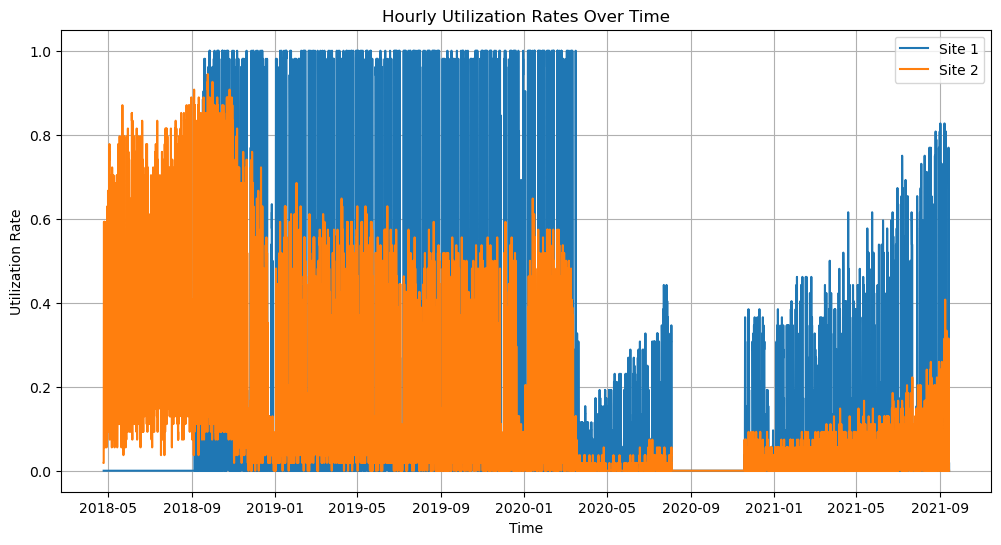

In [17]:
plt.figure(figsize=(12, 6))
for site in total_spaces.keys():
    plt.plot(hourly_df['hour'], hourly_df[f'utilization_{site}'], label=f'Site {site}')

plt.title('Hourly Utilization Rates Over Time')
plt.xlabel('Time')
plt.ylabel('Utilization Rate')
plt.legend()
plt.grid()
plt.show()


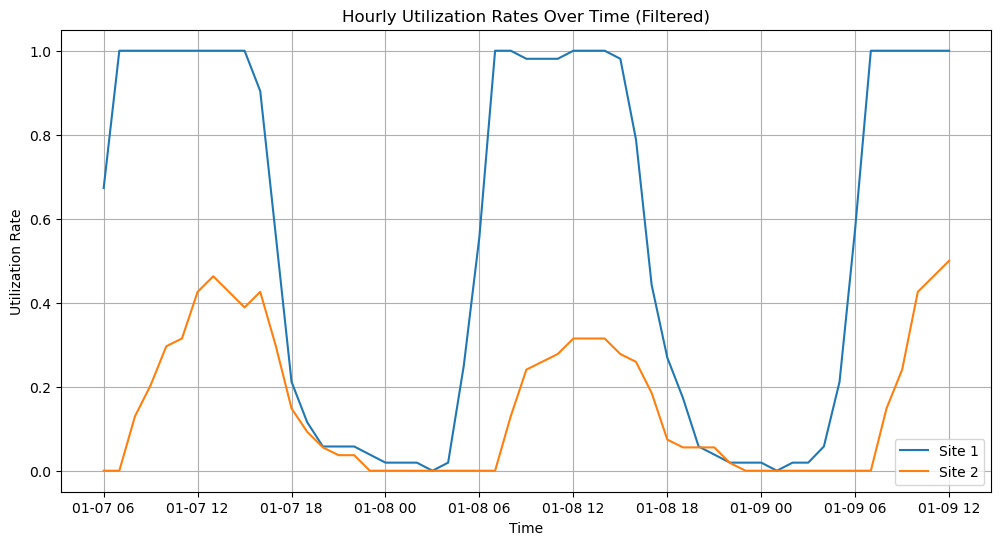

In [18]:
# Filter the timeframe
filtered_start_time = datetime(2020, 1, 7, 6, 0)  # Example start time
filtered_end_time = datetime(2020, 1, 9, 12, 0)  # Example end time
filtered_df = hourly_df[(hourly_df['hour'] >= filtered_start_time) & (hourly_df['hour'] <= filtered_end_time)]

# Visualization
plt.figure(figsize=(12, 6))
for site in total_spaces.keys():
    plt.plot(filtered_df['hour'], filtered_df[f'utilization_{site}'], label=f'Site {site}')

plt.title('Hourly Utilization Rates Over Time (Filtered)')
plt.xlabel('Time')
plt.ylabel('Utilization Rate')
plt.legend()
plt.grid()
plt.show()

## Verify correct computation: look at specific day and compare curve course with actual sessions for site1

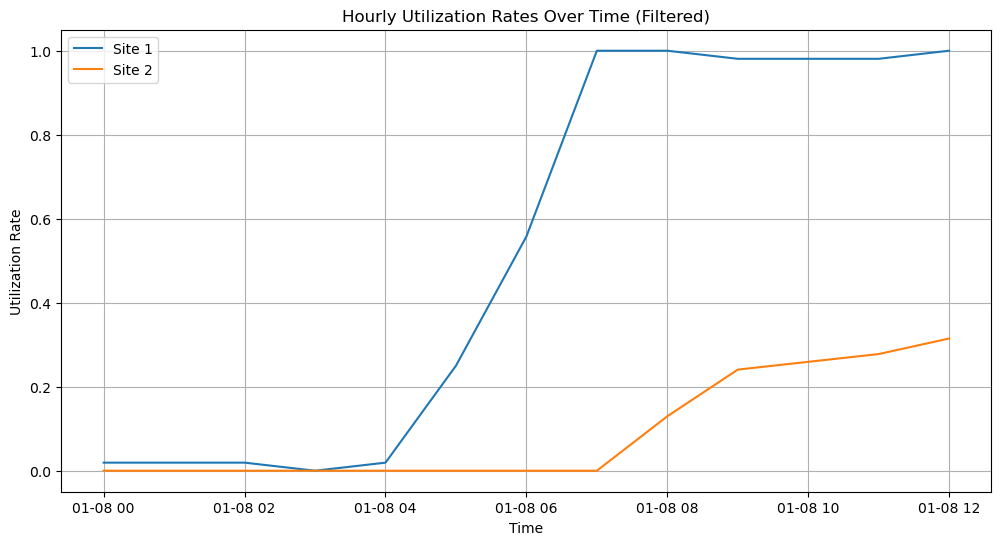

In [19]:
# Filter the timeframe
filtered_start_time = datetime(2020, 1, 8, 0, 0)  # Example start time
filtered_end_time = datetime(2020, 1, 8, 12, 0)  # Example end time
filtered_df = hourly_df[(hourly_df['hour'] >= filtered_start_time) & (hourly_df['hour'] <= filtered_end_time)]

# Visualization
plt.figure(figsize=(12, 6))
for site in total_spaces.keys():
    plt.plot(filtered_df['hour'], filtered_df[f'utilization_{site}'], label=f'Site {site}')

plt.title('Hourly Utilization Rates Over Time (Filtered)')
plt.xlabel('Time')
plt.ylabel('Utilization Rate')
plt.legend()
plt.grid()
plt.show()

### find all sessions on site1 with same timeframe

In [20]:
filtered_start_time = datetime(2020, 1, 8, 0, 0)  # Example start time
filtered_end_time = datetime(2020, 1, 8, 12, 0)  # Example end time
site1[(site1['connectionTime'] >= filtered_start_time) & (site1['connectionTime'] <= filtered_end_time)]

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,chargingDuration
234,234,234,5e2b9a62f9af8b7d745b12fe,2020-01-08 04:39:03,2020-01-08 17:00:49,2020-01-08 14:05:32,32.902000,1_1_194_826_2020-01-08 12:39:02.650912,1,AG-1F11,1-1-194-826,America/Los_Angeles,933.0,566.483333
235,235,235,5e2b9a62f9af8b7d745b12ff,2020-01-08 05:02:37,2020-01-08 14:35:48,2020-01-08 08:03:47,5.807000,1_1_178_828_2020-01-08 13:02:37.451214,1,AG-1F10,1-1-178-828,America/Los_Angeles,3836.0,181.166667
236,236,236,5e2b9a62f9af8b7d745b1300,2020-01-08 05:15:47,2020-01-08 14:51:34,2020-01-08 08:26:36,6.973000,1_1_178_817_2020-01-08 13:15:46.689203,1,AG-1F09,1-1-178-817,America/Los_Angeles,4147.0,190.816667
237,237,237,5e2b9a62f9af8b7d745b1301,2020-01-08 05:37:21,2020-01-08 16:22:58,2020-01-08 11:32:17,12.843000,1_1_194_818_2020-01-08 13:37:08.307398,1,AG-1F14,1-1-194-818,America/Los_Angeles,2362.0,354.933333
238,238,238,5e2b9a62f9af8b7d745b1302,2020-01-08 05:40:58,2020-01-08 15:51:51,2020-01-08 11:25:36,10.771000,1_1_194_822_2020-01-08 13:40:58.412967,1,AG-1F12,1-1-194-822,America/Los_Angeles,3152.0,344.633333
239,239,239,5e2b9a62f9af8b7d745b1303,2020-01-08 05:44:00,2020-01-08 15:27:22,2020-01-08 07:48:37,5.668000,1_1_191_789_2020-01-08 13:44:00.132687,1,AG-4F52,1-1-191-789,America/Los_Angeles,483.0,124.616667
240,240,240,5e2b9a62f9af8b7d745b1304,2020-01-08 05:49:44,2020-01-08 13:44:59,2020-01-08 09:44:05,9.422000,1_1_194_821_2020-01-08 13:49:43.680659,1,AG-1F13,1-1-194-821,America/Los_Angeles,467.0,234.350000
241,241,241,5e2b9a62f9af8b7d745b1305,2020-01-08 05:52:01,2020-01-08 11:50:45,2020-01-08 11:50:45,29.794000,1_1_193_825_2020-01-08 13:52:00.896135,1,AG-1F01,1-1-193-825,America/Los_Angeles,1733.0,358.733333
242,242,242,5e2b9a62f9af8b7d745b1306,2020-01-08 05:53:54,2020-01-08 14:57:51,2020-01-08 09:43:27,13.272000,1_1_193_819_2020-01-08 13:53:54.069131,1,AG-1F06,1-1-193-819,America/Los_Angeles,651.0,229.550000
243,243,243,5e2b9a62f9af8b7d745b1307,2020-01-08 05:53:56,2020-01-08 14:11:07,2020-01-08 14:11:07,31.705000,1_1_178_823_2020-01-08 13:53:35.928280,1,AG-1F08,1-1-178-823,America/Los_Angeles,3687.0,497.183333


## -> seems legit, there is a gap in conncection times between 7:35 and 11:24. same behaviour can be seen in plot above, around 7:30 the utilization rate hits 100%, then declines a bit (some disconnected) and it starts to rise again around 11:30 

In [21]:
#hourly_df.to_csv('Utilization_Rate_Hourly.csv')

# Merge Weather Data

In [22]:
# remove UTC information from timestamp
df_weather['timestamp'] = df_weather['timestamp'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)


In [23]:
df_weather

,Unnamed: 0,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,0,2018-04-25 03:42:00,12.0,27.0,Mostly Cloudy,989.11,11.0,0.0,12.0
1,1,2018-04-25 03:53:00,12.0,26.0,Cloudy,989.11,11.0,0.0,12.0
2,2,2018-04-25 04:53:00,12.0,27.0,Mostly Cloudy,989.11,6.0,0.0,12.0
3,3,2018-04-25 05:10:00,12.0,27.0,Mostly Cloudy,989.11,7.0,0.0,12.0
4,4,2018-04-25 05:53:00,12.0,28.0,Mostly Cloudy,989.11,9.0,0.0,12.0
...,...,...,...,...,...,...,...,...,...
26204,26204,2020-12-31 19:53:00,13.0,33.0,Fair,986.81,0.0,0.0,13.0
26205,26205,2020-12-31 20:53:00,12.0,33.0,Fair,986.81,11.0,0.0,12.0
26206,26206,2020-12-31 21:53:00,12.0,33.0,Fair,987.47,9.0,0.0,12.0
26207,26207,2020-12-31 22:53:00,11.0,33.0,Fair,987.14,13.0,0.0,11.0


In [24]:
# Aggregation of df_weather to hourly values
def aggregate_weather(df_weather):
    df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'])
    df_weather.set_index('timestamp', inplace=True)

    aggregated = df_weather.resample('H').agg({
        'temperature': 'mean',
        'cloud_cover': 'mean',
        'pressure': 'mean',
        'windspeed': 'mean',
        'precipitation': 'mean',
        'felt_temperature': 'mean',
        'cloud_cover_description': lambda x: x.mode().iloc[0] if not x.mode().empty else None
    })

    aggregated.reset_index(inplace=True)
    return aggregated

In [25]:
aggregated_weather = aggregate_weather(df_weather)
aggregated_weather


,timestamp,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-04-25 03:00:00,12.0,26.5,989.11,11.0,0.0,12.0,Cloudy
1,2018-04-25 04:00:00,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 05:00:00,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
3,2018-04-25 06:00:00,12.0,20.0,989.44,8.0,0.0,12.0,Fog
4,2018-04-25 07:00:00,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
...,...,...,...,...,...,...,...,...
23560,2020-12-31 19:00:00,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23561,2020-12-31 20:00:00,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23562,2020-12-31 21:00:00,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23563,2020-12-31 22:00:00,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [26]:
# Remove timestamps not in weather or EV data
hourly_df = hourly_df[hourly_df['hour'] <= datetime(2020, 12, 31, 23, 0)]

aggregated_weather = aggregated_weather[aggregated_weather['timestamp'] != datetime(2018, 4, 25, 3, 0)]


In [27]:
hourly_df

,hour,utilization_1,utilization_2
0,2018-04-25 04:00:00,0.0,0.018519
1,2018-04-25 05:00:00,0.0,0.018519
2,2018-04-25 06:00:00,0.0,0.055556
3,2018-04-25 07:00:00,0.0,0.129630
4,2018-04-25 08:00:00,0.0,0.407407
...,...,...,...
23559,2020-12-31 19:00:00,0.0,0.000000
23560,2020-12-31 20:00:00,0.0,0.000000
23561,2020-12-31 21:00:00,0.0,0.000000
23562,2020-12-31 22:00:00,0.0,0.000000


In [28]:
aggregated_weather

,timestamp,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
1,2018-04-25 04:00:00,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 05:00:00,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
3,2018-04-25 06:00:00,12.0,20.0,989.44,8.0,0.0,12.0,Fog
4,2018-04-25 07:00:00,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
5,2018-04-25 08:00:00,13.5,21.0,990.10,6.0,0.0,13.5,Haze
...,...,...,...,...,...,...,...,...
23560,2020-12-31 19:00:00,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23561,2020-12-31 20:00:00,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23562,2020-12-31 21:00:00,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23563,2020-12-31 22:00:00,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [29]:
# Merge hourly_df and aggregated_weather
def merge_hourly_data(hourly_df, aggregated_weather):
    merged_df = pd.merge(hourly_df, aggregated_weather, left_on='hour', right_on='timestamp', how='inner')
    merged_df.drop(columns=['timestamp'], inplace=True)  # Drop duplicate timestamp column
    return merged_df

In [30]:
merged_df = merge_hourly_data(hourly_df, aggregated_weather)
merged_df

,hour,utilization_1,utilization_2,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-04-25 04:00:00,0.0,0.018519,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
1,2018-04-25 05:00:00,0.0,0.018519,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 06:00:00,0.0,0.055556,12.0,20.0,989.44,8.0,0.0,12.0,Fog
3,2018-04-25 07:00:00,0.0,0.129630,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
4,2018-04-25 08:00:00,0.0,0.407407,13.5,21.0,990.10,6.0,0.0,13.5,Haze
...,...,...,...,...,...,...,...,...,...,...
23559,2020-12-31 19:00:00,0.0,0.000000,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23560,2020-12-31 20:00:00,0.0,0.000000,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23561,2020-12-31 21:00:00,0.0,0.000000,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23562,2020-12-31 22:00:00,0.0,0.000000,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [202]:
# Split the merged_df into two datasets for utilization_1 and utilization_2
def split_merged_data(merged_df):
    # Split for utilization_1
    utilization_1_df = merged_df[merged_df['hour'] >= datetime(2018, 10, 8, 6, 0)].copy() # Filter rows where activity on site starts 
    utilization_1_df.drop(columns=['utilization_2'], inplace=True)

    # Split for utilization_2
    utilization_2_df = merged_df.copy()
    utilization_2_df.drop(columns=['utilization_1'], inplace=True)

    return utilization_1_df, utilization_2_df

In [203]:
utilization_1_df, utilization_2_df = split_merged_data(merged_df)
utilization_1_df = utilization_1_df.reset_index(drop=True)


In [204]:
utilization_1_df # before adding features

,hour,utilization_1,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-10-08 06:00:00,0.480769,13.000000,34.000000,982.53,0.0,0.0,13.000000,Fair
1,2018-10-08 07:00:00,1.000000,14.333333,29.333333,982.86,0.0,0.0,14.333333,Partly Cloudy
2,2018-10-08 08:00:00,1.000000,17.000000,30.000000,983.19,0.0,0.0,17.000000,Partly Cloudy
3,2018-10-08 09:00:00,1.000000,18.000000,34.000000,983.19,6.0,0.0,18.000000,Fair
4,2018-10-08 10:00:00,1.000000,20.000000,34.000000,983.19,7.0,0.0,20.000000,Fair
...,...,...,...,...,...,...,...,...,...
19573,2020-12-31 19:00:00,0.000000,13.000000,33.000000,986.81,0.0,0.0,13.000000,Fair
19574,2020-12-31 20:00:00,0.000000,12.000000,33.000000,986.81,11.0,0.0,12.000000,Fair
19575,2020-12-31 21:00:00,0.000000,12.000000,33.000000,987.47,9.0,0.0,12.000000,Fair
19576,2020-12-31 22:00:00,0.000000,11.000000,33.000000,987.14,13.0,0.0,11.000000,Fair


In [165]:
utilization_2_df

,hour,utilization_2,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-04-25 04:00:00,0.018519,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
1,2018-04-25 05:00:00,0.018519,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 06:00:00,0.055556,12.0,20.0,989.44,8.0,0.0,12.0,Fog
3,2018-04-25 07:00:00,0.129630,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
4,2018-04-25 08:00:00,0.407407,13.5,21.0,990.10,6.0,0.0,13.5,Haze
...,...,...,...,...,...,...,...,...,...
23559,2020-12-31 19:00:00,0.000000,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23560,2020-12-31 20:00:00,0.000000,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23561,2020-12-31 21:00:00,0.000000,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23562,2020-12-31 22:00:00,0.000000,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [199]:
def add_features(df):
    df['is_weekend'] = df['hour'].dt.weekday.isin([5, 6]).astype(int)
    weekdays = ['is_monday', 'is_tuesday', 'is_wednesday', 'is_thursday', 'is_friday', 'is_saturday', 'is_sunday']
    for i, day in enumerate(weekdays):
        df[day] = (df['hour'].dt.weekday == i).astype(int)
    df['hour_of_day_sin'] = np.sin(2 * np.pi * df['hour'].dt.hour / 24)
    df['hour_of_day_cos'] = np.cos(2 * np.pi * df['hour'].dt.hour / 24)
    df['trend'] = (df['hour'] - df['hour'].min()).dt.days

    # Normalize monthly average utilization
    df['month'] = df['hour'].dt.month
    monthly_avg = df.groupby('month')['utilization_1' if 'utilization_1' in df else 'utilization_2'].mean()
    monthly_avg_normalized = monthly_avg / monthly_avg.max()
    df = df.merge(monthly_avg_normalized, on='month', suffixes=('', '_normalized'))

    # Add lagged utilization
    if 'utilization_1' in df:
        df['utilization_1_lagged'] = df['utilization_1'].shift(1)
        df.rename(columns={'utilization_1_normalized': 'monthly_util_normalized'}, inplace=True)
    if 'utilization_2' in df:
        df['utilization_2_lagged'] = df['utilization_2'].shift(1)
        df.rename(columns={'utilization_2_normalized': 'monthly_util_normalized'}, inplace=True)

    # Add lockdown feature
    lockdown_start = pd.Timestamp(2020, 8, 3, 22, 0)
    lockdown_end = pd.Timestamp(2020, 11, 18, 11, 0)
    df['is_lockdown'] = ((df['hour'] >= lockdown_start) & (df['hour'] <= lockdown_end)).astype(int)

    return df

In [205]:
utilization_1_df['original_order'] = utilization_1_df.index
utilization_1_df = add_features(utilization_1_df)
utilization_1_df = utilization_1_df.sort_values('original_order').drop(columns='original_order').reset_index(drop=True)

utilization_2_df['original_order'] = utilization_2_df.index
utilization_2_df = add_features(utilization_2_df)
utilization_2_df = utilization_2_df.sort_values('original_order').drop(columns='original_order').reset_index(drop=True)


In [206]:
utilization_1_df #after adding features

,hour,utilization_1,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description,is_weekend,...,is_friday,is_saturday,is_sunday,hour_of_day_sin,hour_of_day_cos,trend,month,monthly_util_normalized,utilization_1_lagged,is_lockdown
0,2018-10-08 06:00:00,0.480769,13.000000,34.000000,982.53,0.0,0.0,13.000000,Fair,0,...,0,0,0,1.000000,6.123234e-17,0,10,0.717227,NaN,0
1,2018-10-08 07:00:00,1.000000,14.333333,29.333333,982.86,0.0,0.0,14.333333,Partly Cloudy,0,...,0,0,0,0.965926,-2.588190e-01,0,10,0.717227,0.480769,0
2,2018-10-08 08:00:00,1.000000,17.000000,30.000000,983.19,0.0,0.0,17.000000,Partly Cloudy,0,...,0,0,0,0.866025,-5.000000e-01,0,10,0.717227,1.000000,0
3,2018-10-08 09:00:00,1.000000,18.000000,34.000000,983.19,6.0,0.0,18.000000,Fair,0,...,0,0,0,0.707107,-7.071068e-01,0,10,0.717227,1.000000,0
4,2018-10-08 10:00:00,1.000000,20.000000,34.000000,983.19,7.0,0.0,20.000000,Fair,0,...,0,0,0,0.500000,-8.660254e-01,0,10,0.717227,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19573,2020-12-31 19:00:00,0.000000,13.000000,33.000000,986.81,0.0,0.0,13.000000,Fair,0,...,0,0,0,-0.965926,2.588190e-01,815,12,0.614026,0.000000,0
19574,2020-12-31 20:00:00,0.000000,12.000000,33.000000,986.81,11.0,0.0,12.000000,Fair,0,...,0,0,0,-0.866025,5.000000e-01,815,12,0.614026,0.000000,0
19575,2020-12-31 21:00:00,0.000000,12.000000,33.000000,987.47,9.0,0.0,12.000000,Fair,0,...,0,0,0,-0.707107,7.071068e-01,815,12,0.614026,0.000000,0
19576,2020-12-31 22:00:00,0.000000,11.000000,33.000000,987.14,13.0,0.0,11.000000,Fair,0,...,0,0,0,-0.500000,8.660254e-01,815,12,0.614026,0.000000,0


In [169]:
utilization_2_df


,hour,utilization_2,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description,is_weekend,...,is_thursday,is_friday,is_saturday,is_sunday,hour_of_day_sin,hour_of_day_cos,trend,month,monthly_util_normalized,utilization_2_lagged
0,2018-04-25 04:00:00,0.018519,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy,0,...,0,0,0,0,0.866025,5.000000e-01,0,4,0.594385,NaN
1,2018-04-25 05:00:00,0.018519,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy,0,...,0,0,0,0,0.965926,2.588190e-01,0,4,0.594385,0.018519
2,2018-04-25 06:00:00,0.055556,12.0,20.0,989.44,8.0,0.0,12.0,Fog,0,...,0,0,0,0,1.000000,6.123234e-17,0,4,0.594385,0.018519
3,2018-04-25 07:00:00,0.129630,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy,0,...,0,0,0,0,0.965926,-2.588190e-01,0,4,0.594385,0.055556
4,2018-04-25 08:00:00,0.407407,13.5,21.0,990.10,6.0,0.0,13.5,Haze,0,...,0,0,0,0,0.866025,-5.000000e-01,0,4,0.594385,0.129630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23559,2020-12-31 19:00:00,0.000000,13.0,33.0,986.81,0.0,0.0,13.0,Fair,0,...,1,0,0,0,-0.965926,2.588190e-01,981,12,0.492706,0.000000
23560,2020-12-31 20:00:00,0.000000,12.0,33.0,986.81,11.0,0.0,12.0,Fair,0,...,1,0,0,0,-0.866025,5.000000e-01,981,12,0.492706,0.000000
23561,2020-12-31 21:00:00,0.000000,12.0,33.0,987.47,9.0,0.0,12.0,Fair,0,...,1,0,0,0,-0.707107,7.071068e-01,981,12,0.492706,0.000000
23562,2020-12-31 22:00:00,0.000000,11.0,33.0,987.14,13.0,0.0,11.0,Fair,0,...,1,0,0,0,-0.500000,8.660254e-01,981,12,0.492706,0.000000


In [161]:
utilization_1_df.hour.max() # max timestamp after adding features 

Timestamp('2020-12-31 23:00:00')

In [279]:
def plot_week_predictions(actuals, predictions, start_date, end_date):
    """
    Plot actuals (from utilization_1_df) and predictions for a specific date range.

    Parameters:
    - actuals (pd.DataFrame): DataFrame containing the 'hour' column (timestamps) and 'utilization_1' (actual values).
    - predictions (pd.Series): Series of predicted values with datetime index.
    - start_date (str or pd.Timestamp): Start date for the plot (inclusive).
    - end_date (str or pd.Timestamp): End date for the plot (inclusive).
    """
    # Ensure end_date includes only up to the last hour of the specified day
    end_date = pd.Timestamp(end_date) + pd.Timedelta(hours=23, minutes=59, seconds=59)

    # Filter utilization_1_df for the specified date range
    actuals_week = actuals[
        (actuals['hour'] >= pd.Timestamp(start_date)) & 
        (actuals['hour'] <= end_date)
    ]

    if 'utilization_1' in actuals.columns:
        actuals_week = actuals_week.set_index('hour')['utilization_1']
    elif 'utilization_2' in actuals.columns:
        actuals_week = actuals_week.set_index('hour')['utilization_2']
    else:
        raise ValueError("The actuals DataFrame must contain either 'utilization_1' or 'utilization_2'.")


    # Filter predictions for the specified date range
    predictions_week = predictions.loc[start_date:end_date]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(actuals_week, label='Actual', alpha=0.7)
    plt.plot(predictions_week, label='Predicted', alpha=0.7)
    plt.title(f'ARIMAX Model: Predictions vs Actuals ({start_date} to {end_date.date()})')
    plt.xlabel('Date')
    plt.ylabel('Utilization Rate')
    plt.legend()
    plt.grid()
    plt.show()


In [170]:
# this are all features that could possibly be used 
utilization_1_df.columns

Index(['hour', 'utilization_1', 'temperature', 'cloud_cover', 'pressure',
       'windspeed', 'precipitation', 'felt_temperature',
       'cloud_cover_description', 'is_weekend', 'is_monday', 'is_tuesday',
       'is_wednesday', 'is_thursday', 'is_friday', 'is_saturday', 'is_sunday',
       'hour_of_day_sin', 'hour_of_day_cos', 'trend', 'month',
       'monthly_util_normalized', 'utilization_1_lagged'],
      dtype='object')

# 1. Model: ARIMAX

In [316]:
def train_arimax_with_holdout_site_1(utilization_1_df):
    # Filter out data after the specified date (exclude COVID anomaly)
    end_date = pd.Timestamp(2020, 3, 17, 0, 0)
    holdout_start = pd.Timestamp(2020, 1, 1, 0, 0)
    utilization_1_df = utilization_1_df[utilization_1_df['hour'] <= end_date]

    # Define the holdout set
    holdout_set = utilization_1_df[utilization_1_df['hour'] >= holdout_start]
    train_set = utilization_1_df[utilization_1_df['hour'] < holdout_start]

    # Select features and target variable
    features = [
        'felt_temperature', 'windspeed',
        'is_weekend', 'hour_of_day_sin', 'monthly_util_normalized', 'utilization_1_lagged'
    ]
    target = 'utilization_1'

    # Drop rows with NaN values (e.g., first lagged value)
    train_set = train_set.dropna(subset=features + [target])
    holdout_set = holdout_set.dropna(subset=features + [target])

    X_train = train_set[features]
    y_train = train_set[target]
    X_holdout = holdout_set[features]
    y_holdout = holdout_set[target]
    timestamps_holdout = holdout_set['hour']

    # Split data into cross-validation folds using TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    all_predictions = []
    all_actuals = []
    all_timestamps = []

    for train_index, test_index in tscv.split(X_train):
        X_train_cv, X_test_cv = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_cv, y_test_cv = y_train.iloc[train_index], y_train.iloc[test_index]
        timestamp_train = train_set['hour'].iloc[train_index]
        timestamp_test = train_set['hour'].iloc[test_index]

        print(f"Train start: {timestamp_train.iloc[0]}, Train end: {timestamp_train.iloc[-1]}")
        print(f"Test start: {timestamp_test.iloc[0]}, Test end: {timestamp_test.iloc[-1]}")

        # Train ARIMAX model
        model = SARIMAX(y_train_cv, exog=X_train_cv, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
        model_fit = model.fit(disp=False)

        # Predict on the test set
        y_pred_cv = model_fit.forecast(steps=len(y_test_cv), exog=X_test_cv)

        # Evaluate the model
        rmse = mean_squared_error(y_test_cv, y_pred_cv, squared=False)
        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        r2 = r2_score(y_test_cv, y_pred_cv)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        all_predictions.extend(y_pred_cv)
        all_actuals.extend(y_test_cv)
        all_timestamps.extend(timestamp_test)

    # Print cross-validation metrics
    print(f"Cross-Validation RMSE: {np.mean(rmse_scores):.4f}")
    print(f"Cross-Validation MAE: {np.mean(mae_scores):.4f}")
    print(f"Cross-Validation R²: {np.mean(r2_scores):.4f}")

    # Train a final model on the full training set
    final_model = SARIMAX(y_train, exog=X_train, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
    final_model_fit = final_model.fit(disp=False)

    # Evaluate on the holdout set using the final model
    holdout_predictions = final_model_fit.forecast(steps=len(y_holdout), exog=X_holdout)
    holdout_rmse = mean_squared_error(y_holdout, holdout_predictions, squared=False)
    holdout_mae = mean_absolute_error(y_holdout, holdout_predictions)
    holdout_r2 = r2_score(y_holdout, holdout_predictions)

    print(f"Holdout RMSE: {holdout_rmse:.4f}")
    print(f"Holdout MAE: {holdout_mae:.4f}")
    print(f"Holdout R²: {holdout_r2:.4f}")

    timestamps_holdout = timestamps_holdout.reset_index(drop=True)
    holdout_predictions = pd.Series(holdout_predictions).reset_index(drop=True)

    # Plot predictions vs actuals on the holdout set
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps_holdout, y_holdout, label='Actual', alpha=0.7)
    plt.plot(timestamps_holdout, holdout_predictions, label='Predicted', alpha=0.7)
    plt.title('ARIMAX Model: Predictions vs Actual Utilization (Holdout Set)')
    plt.xlabel('Time')
    plt.ylabel('Utilization Rate')
    plt.legend()
    plt.grid()
    plt.show()

    return final_model_fit, pd.Series(all_actuals, index=all_timestamps, name='Actuals'), pd.Series(all_predictions, index=all_timestamps, name='Predictions'), pd.Series(holdout_predictions.values, index=timestamps_holdout, name='Holdout Predictions')


In [270]:
def train_arimax_with_holdout_site_2(utilization_2_df):
    # Filter out data after the specified date (exclude COVID anomaly)
    end_date = pd.Timestamp(2020, 3, 17, 0, 0)
    holdout_start = pd.Timestamp(2020, 1, 1, 0, 0)
    utilization_2_df = utilization_2_df[utilization_2_df['hour'] <= end_date]

    # Define the holdout set
    holdout_set = utilization_2_df[utilization_2_df['hour'] >= holdout_start]
    train_set = utilization_2_df[utilization_2_df['hour'] < holdout_start]

    # Select features and target variable
    features = [
        'felt_temperature', 'windspeed',
        'is_weekend', 'hour_of_day_sin', 'monthly_util_normalized', 'utilization_2_lagged'
    ]
    target = 'utilization_2'

    # Drop rows with NaN values (e.g., first lagged value)
    train_set = train_set.dropna(subset=features + [target])
    holdout_set = holdout_set.dropna(subset=features + [target])

    X_train = train_set[features]
    y_train = train_set[target]
    X_holdout = holdout_set[features]
    y_holdout = holdout_set[target]
    timestamps_holdout = holdout_set['hour']

    # Split data into cross-validation folds using TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    all_predictions = []
    all_actuals = []
    all_timestamps = []

    for train_index, test_index in tscv.split(X_train):
        X_train_cv, X_test_cv = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_cv, y_test_cv = y_train.iloc[train_index], y_train.iloc[test_index]
        timestamp_train = train_set['hour'].iloc[train_index]
        timestamp_test = train_set['hour'].iloc[test_index]

        print(f"Train start: {timestamp_train.iloc[0]}, Train end: {timestamp_train.iloc[-1]}")
        print(f"Test start: {timestamp_test.iloc[0]}, Test end: {timestamp_test.iloc[-1]}")

        # Train ARIMAX model
        model = SARIMAX(y_train_cv, exog=X_train_cv, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
        model_fit = model.fit(disp=False)

        # Predict on the test set
        y_pred_cv = model_fit.forecast(steps=len(y_test_cv), exog=X_test_cv)

        # Evaluate the model
        rmse = mean_squared_error(y_test_cv, y_pred_cv, squared=False)
        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        r2 = r2_score(y_test_cv, y_pred_cv)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        all_predictions.extend(y_pred_cv)
        all_actuals.extend(y_test_cv)
        all_timestamps.extend(timestamp_test)

    # Print cross-validation metrics
    print(f"Cross-Validation RMSE: {np.mean(rmse_scores):.4f}")
    print(f"Cross-Validation MAE: {np.mean(mae_scores):.4f}")
    print(f"Cross-Validation R²: {np.mean(r2_scores):.4f}")

    # Train a final model on the full training set
    final_model = SARIMAX(y_train, exog=X_train, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
    final_model_fit = final_model.fit(disp=False)

    # Evaluate on the holdout set using the final model
    holdout_predictions = final_model_fit.forecast(steps=len(y_holdout), exog=X_holdout)
    holdout_rmse = mean_squared_error(y_holdout, holdout_predictions, squared=False)
    holdout_mae = mean_absolute_error(y_holdout, holdout_predictions)
    holdout_r2 = r2_score(y_holdout, holdout_predictions)

    print(f"Holdout RMSE: {holdout_rmse:.4f}")
    print(f"Holdout MAE: {holdout_mae:.4f}")
    print(f"Holdout R²: {holdout_r2:.4f}")

    timestamps_holdout = timestamps_holdout.reset_index(drop=True)
    holdout_predictions = pd.Series(holdout_predictions).reset_index(drop=True)

    # Plot predictions vs actuals on the holdout set
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps_holdout, y_holdout, label='Actual', alpha=0.7)
    plt.plot(timestamps_holdout, holdout_predictions, label='Predicted', alpha=0.7)
    plt.title('ARIMAX Model: Predictions vs Actual Utilization (Holdout Set)')
    plt.xlabel('Time')
    plt.ylabel('Utilization Rate')
    plt.legend()
    plt.grid()
    plt.show()

    return final_model_fit, pd.Series(all_actuals, index=all_timestamps, name='Actuals'), pd.Series(all_predictions, index=all_timestamps, name='Predictions'), pd.Series(holdout_predictions.values, index=timestamps_holdout, name='Holdout Predictions')


# exlude features:
- temperature (P-value = 0.109) - only use either temperature or felt_temperature
- flags for weekdays
- trend
- precipitation
- cloud cover
- pressure 

## Site 1 ARIMAX

Train start: 2018-10-08 07:00:00, Train end: 2018-12-22 03:00:00
Test start: 2018-12-22 04:00:00, Test end: 2019-03-06 22:00:00
Train start: 2018-10-08 07:00:00, Train end: 2019-03-06 22:00:00
Test start: 2019-03-06 23:00:00, Test end: 2019-05-20 19:00:00
Train start: 2018-10-08 07:00:00, Train end: 2019-05-20 19:00:00
Test start: 2019-05-20 20:00:00, Test end: 2019-08-04 07:00:00
Train start: 2018-10-08 07:00:00, Train end: 2019-08-04 07:00:00
Test start: 2019-08-04 08:00:00, Test end: 2019-10-18 04:00:00
Train start: 2018-10-08 07:00:00, Train end: 2019-10-18 04:00:00
Test start: 2019-10-18 05:00:00, Test end: 2019-12-31 23:00:00
Cross-Validation RMSE: 0.1085
Cross-Validation MAE: 0.0753
Cross-Validation R²: 0.9272
Holdout RMSE: 0.1018
Holdout MAE: 0.0721
Holdout R²: 0.9348


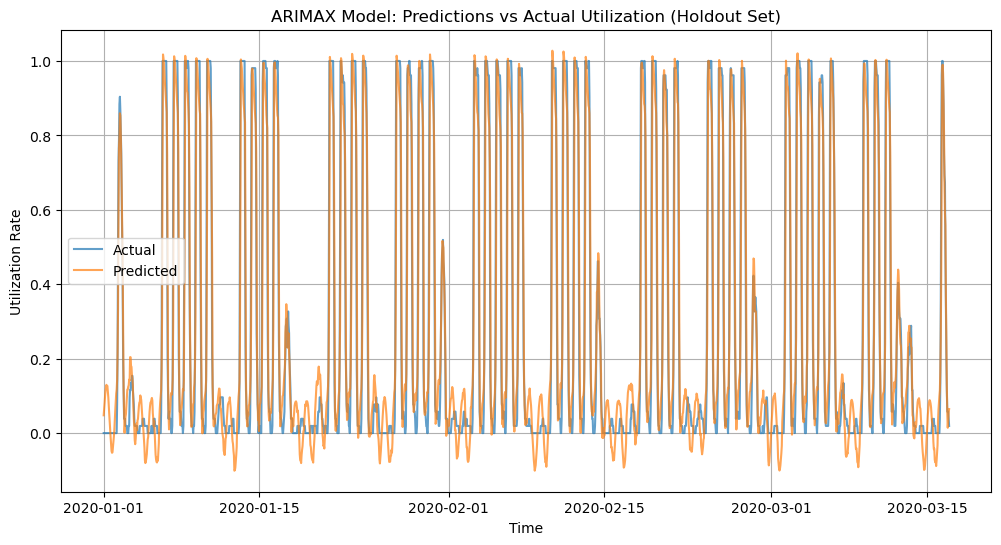

In [317]:
arimax_model_site_1, all_actuals_arimax_site_1, all_predictions_arimax_site_1, holdout_predictions_arimax_site_1 = train_arimax_with_holdout_site_1(utilization_1_df)

In [318]:
arimax_model_site_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          utilization_1   No. Observations:                10770
Model:               SARIMAX(1, 0, 1)   Log Likelihood               11278.941
Date:                Sun, 26 Jan 2025   AIC                         -22539.881
Time:                        16:46:01   BIC                         -22474.321
Sample:                             0   HQIC                        -22517.771
                              - 10770                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
felt_temperature            0.0017      0.000      6.713      0.000       0.001       0.002
windspeed                   0.0005      0.000      3.130      0.002       0.000       0.001
is_weekend                 -0.0411      0.008     -5.098      0.000      -0.057      -0.025
hour_of_day_sin             0.0975      0.003     32.044      0.000       0.092       0.103
monthly_util_normalized     0.0172      0.006      2.818      0.005       0.005       0.029
utilization_1_lagged        0.8889      0.009     96.436      0.000       0.871       0.907
ar.L1                       0.2310      0.022     10.362      0.000       0.187       0.275
ma.L1                       0.4861      0.016     29.606      0.000       0.454       0.518
sigma2                      0.0073   9.08e-05     80.170      0.000       0.007       0.007
===================================================================================
Ljung-Box (L1) (Q):                   2.06   Jarque-Bera (JB):              9030.69
Prob(Q):                              0.15   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                             0.50
Prob(H) (two-sided):                  0.06   Kurtosis:                         7.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

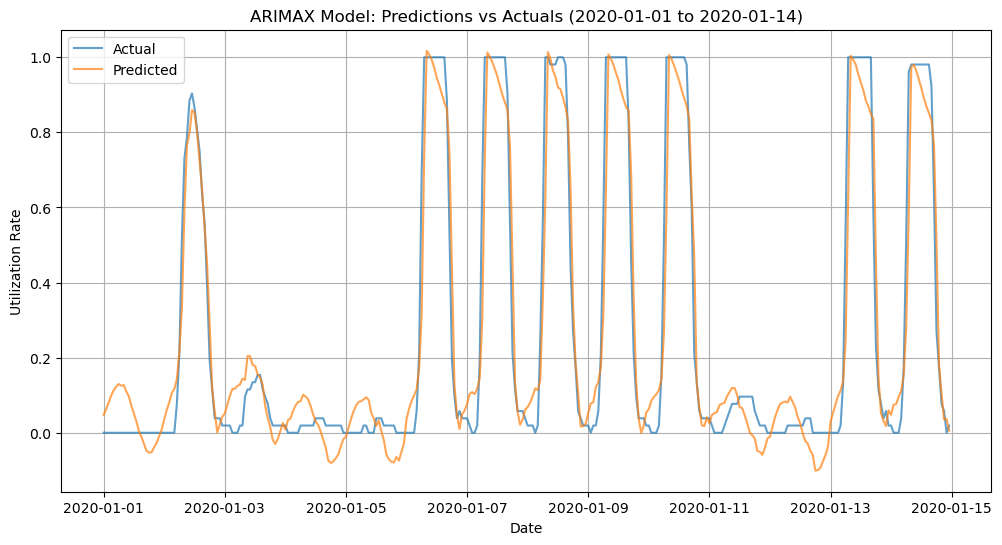

In [319]:
# Define the date range
start_date = "2020-01-01"
end_date = "2020-01-14"

plot_week_predictions(utilization_1_df, holdout_predictions_arimax_site_1, start_date, end_date)


## Site 2 ARIMAX

Train start: 2018-04-25 05:00:00, Train end: 2018-08-05 22:00:00
Test start: 2018-08-05 23:00:00, Test end: 2018-11-16 17:00:00
Train start: 2018-04-25 05:00:00, Train end: 2018-11-16 17:00:00
Test start: 2018-11-16 18:00:00, Test end: 2019-02-27 02:00:00
Train start: 2018-04-25 05:00:00, Train end: 2019-02-27 02:00:00
Test start: 2019-02-27 03:00:00, Test end: 2019-06-10 04:00:00
Train start: 2018-04-25 05:00:00, Train end: 2019-06-10 04:00:00
Test start: 2019-06-10 05:00:00, Test end: 2019-09-20 14:00:00
Train start: 2018-04-25 05:00:00, Train end: 2019-09-20 14:00:00
Test start: 2019-09-20 15:00:00, Test end: 2019-12-31 23:00:00
Cross-Validation RMSE: 0.0545
Cross-Validation MAE: 0.0414
Cross-Validation R²: 0.9233
Holdout RMSE: 0.0482
Holdout MAE: 0.0348
Holdout R²: 0.9282


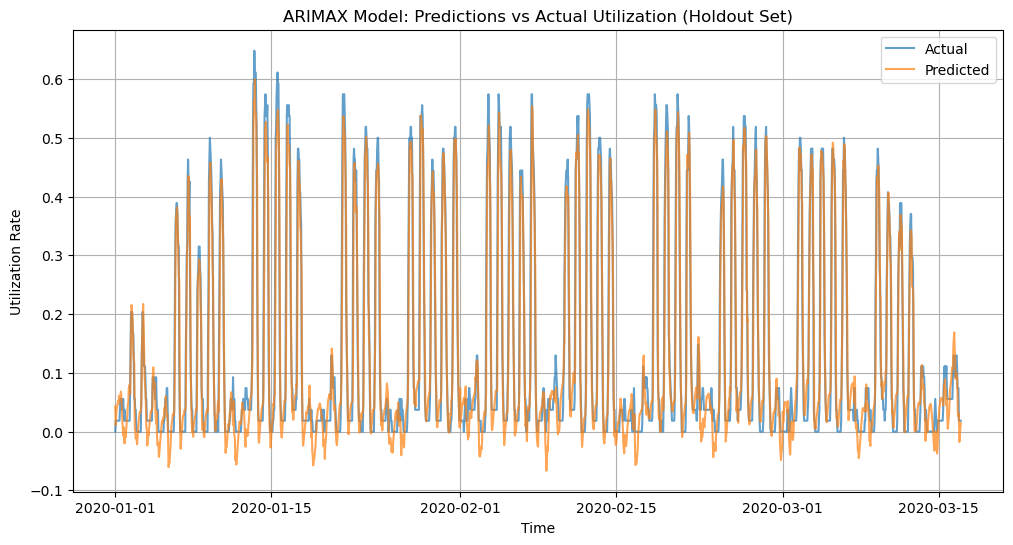

In [320]:
arimax_model_site_2, all_actuals_arimax_site_2, all_predictions_arimax_site_2, holdout_predictions_arimax_site_2 = train_arimax_with_holdout_site_2(utilization_2_df)

In [321]:
arimax_model_site_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          utilization_2   No. Observations:                14740
Model:               SARIMAX(1, 0, 1)   Log Likelihood               23640.939
Date:                Sun, 26 Jan 2025   AIC                         -47263.879
Time:                        16:48:22   BIC                         -47195.494
Sample:                             0   HQIC                        -47241.170
                              - 14740                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
felt_temperature            0.0028      0.000     17.457      0.000       0.003       0.003
windspeed                   0.0004   9.13e-05      4.901      0.000       0.000       0.001
is_weekend                 -0.0123      0.003     -4.775      0.000      -0.017      -0.007
hour_of_day_sin             0.0494      0.001     33.782      0.000       0.047       0.052
monthly_util_normalized    -0.0439      0.004    -12.345      0.000      -0.051      -0.037
utilization_2_lagged        0.9257      0.007    141.820      0.000       0.913       0.938
ar.L1                       0.3824      0.021     18.604      0.000       0.342       0.423
ma.L1                       0.1362      0.018      7.538      0.000       0.101       0.172
sigma2                      0.0024   1.72e-05    136.956      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):             52645.09
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               0.41   Skew:                             1.30
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

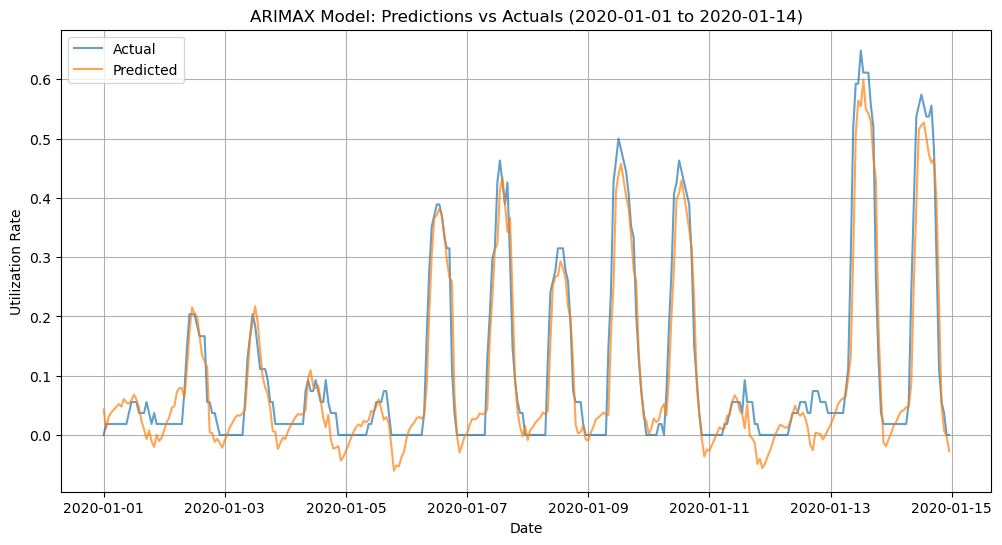

In [322]:
# Define the date range
start_date = "2020-01-01"
end_date = "2020-01-14"

plot_week_predictions(utilization_2_df, holdout_predictions_arimax_site_2, start_date, end_date)

# 2 Model (Neural Network): LSTM

In [307]:
# Function to create LSTM model
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.3),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='mse',
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

# Function to train LSTM model with cross-validation and holdout set
def train_lstm_with_holdout_1(utilization_df):
    # Filter out data after the specified date (exclude COVID anomaly)
    end_date = pd.Timestamp(2020, 3, 17, 0, 0)
    holdout_start = pd.Timestamp(2020, 1, 1, 0, 0)
    utilization_df = utilization_df[utilization_df['hour'] <= end_date]

    # Define the holdout set
    holdout_set = utilization_df[utilization_df['hour'] >= holdout_start]
    train_set = utilization_df[utilization_df['hour'] < holdout_start]

    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss', patience=3, factor=0.5, min_lr=1e-5)

    # Select features and target variable
    features = [
        'felt_temperature', 'cloud_cover', 'pressure', 'windspeed', 'precipitation',
        'is_weekend', 'hour_of_day_sin', 'monthly_util_normalized', 'utilization_1_lagged'
    ]
    target = 'utilization_1'

    # Drop rows with NaN values (e.g., first lagged value)
    train_set = train_set.dropna(subset=features + [target])
    holdout_set = holdout_set.dropna(subset=features + [target])

    X_train = train_set[features].values
    y_train = train_set[target].values
    X_holdout = holdout_set[features].values
    y_holdout = holdout_set[target].values
    timestamps_holdout = holdout_set['hour']

    # Reshape input data for LSTM [samples, time steps, features]
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_holdout = X_holdout.reshape((X_holdout.shape[0], 1, X_holdout.shape[1]))

    # Split data into cross-validation folds
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    all_predictions = []
    all_actuals = []
    all_timestamps = []

    for train_index, test_index in tscv.split(X_train):
        X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
        y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]
        timestamp_test = train_set['hour'].iloc[test_index]

        # Create and train the model
        model = create_lstm_model(input_shape=(X_train_cv.shape[1], X_train_cv.shape[2]))
        model.fit(X_train_cv, y_train_cv, epochs=50, batch_size=32, verbose=0, callbacks=[lr_schedule])
        

        # Predict on the test set
        y_pred_cv = model.predict(X_test_cv).flatten()

        # Evaluate the model
        rmse = mean_squared_error(y_test_cv, y_pred_cv, squared=False)
        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        r2 = r2_score(y_test_cv, y_pred_cv)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        all_predictions.extend(y_pred_cv)
        all_actuals.extend(y_test_cv)
        all_timestamps.extend(timestamp_test)

    # Print cross-validation metrics
    print(f"Cross-Validation RMSE: {np.mean(rmse_scores):.4f}")
    print(f"Cross-Validation MAE: {np.mean(mae_scores):.4f}")
    print(f"Cross-Validation R²: {np.mean(r2_scores):.4f}")

    # Train final model on the full training set
    final_model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
    final_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, callbacks=[lr_schedule])

    # Evaluate on the holdout set
    holdout_predictions = final_model.predict(X_holdout).flatten()
    holdout_rmse = mean_squared_error(y_holdout, holdout_predictions, squared=False)
    holdout_mae = mean_absolute_error(y_holdout, holdout_predictions)
    holdout_r2 = r2_score(y_holdout, holdout_predictions)

    print(f"Holdout RMSE: {holdout_rmse:.4f}")
    print(f"Holdout MAE: {holdout_mae:.4f}")
    print(f"Holdout R²: {holdout_r2:.4f}")

    # Plot predictions vs actuals on the holdout set
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps_holdout, y_holdout, label='Actual', alpha=0.7)
    plt.plot(timestamps_holdout, holdout_predictions, label='Predicted', alpha=0.7)
    plt.title('LSTM Model: Predictions vs Actual Utilization (Holdout Set)')
    plt.xlabel('Time')
    plt.ylabel('Utilization Rate')
    plt.legend()
    plt.grid()
    plt.show()

    return final_model, pd.Series(all_actuals, index=all_timestamps, name='Actuals'), pd.Series(all_predictions, index=all_timestamps, name='Predictions'), pd.Series(holdout_predictions, index=timestamps_holdout, name='Holdout Predictions')


# site 2
def train_lstm_with_holdout_2(utilization_df):
    # Filter out data after the specified date (exclude COVID anomaly)
    end_date = pd.Timestamp(2020, 3, 17, 0, 0)
    holdout_start = pd.Timestamp(2020, 1, 1, 0, 0)
    utilization_df = utilization_df[utilization_df['hour'] <= end_date]

    # Define the holdout set
    holdout_set = utilization_df[utilization_df['hour'] >= holdout_start]
    train_set = utilization_df[utilization_df['hour'] < holdout_start]

    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss', patience=3, factor=0.5, min_lr=1e-5)

    # Select features and target variable
    features = [
        'felt_temperature', 'cloud_cover', 'pressure', 'windspeed', 'precipitation',
        'is_weekend', 'hour_of_day_sin', 'monthly_util_normalized', 'utilization_2_lagged'
    ]
    target = 'utilization_2'

    # Drop rows with NaN values (e.g., first lagged value)
    train_set = train_set.dropna(subset=features + [target])
    holdout_set = holdout_set.dropna(subset=features + [target])

    X_train = train_set[features].values
    y_train = train_set[target].values
    X_holdout = holdout_set[features].values
    y_holdout = holdout_set[target].values
    timestamps_holdout = holdout_set['hour']

    # Reshape input data for LSTM [samples, time steps, features]
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_holdout = X_holdout.reshape((X_holdout.shape[0], 1, X_holdout.shape[1]))

    # Split data into cross-validation folds
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    all_predictions = []
    all_actuals = []
    all_timestamps = []

    for train_index, test_index in tscv.split(X_train):
        X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
        y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]
        timestamp_test = train_set['hour'].iloc[test_index]

        # Create and train the model
        model = create_lstm_model(input_shape=(X_train_cv.shape[1], X_train_cv.shape[2]))
        model.fit(X_train_cv, y_train_cv, epochs=50, batch_size=32, verbose=0, callbacks=[lr_schedule])
        

        # Predict on the test set
        y_pred_cv = model.predict(X_test_cv).flatten()

        # Evaluate the model
        rmse = mean_squared_error(y_test_cv, y_pred_cv, squared=False)
        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        r2 = r2_score(y_test_cv, y_pred_cv)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        all_predictions.extend(y_pred_cv)
        all_actuals.extend(y_test_cv)
        all_timestamps.extend(timestamp_test)

    # Print cross-validation metrics
    print(f"Cross-Validation RMSE: {np.mean(rmse_scores):.4f}")
    print(f"Cross-Validation MAE: {np.mean(mae_scores):.4f}")
    print(f"Cross-Validation R²: {np.mean(r2_scores):.4f}")

    # Train final model on the full training set
    final_model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
    final_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, callbacks=[lr_schedule])

    # Evaluate on the holdout set
    holdout_predictions = final_model.predict(X_holdout).flatten()
    holdout_rmse = mean_squared_error(y_holdout, holdout_predictions, squared=False)
    holdout_mae = mean_absolute_error(y_holdout, holdout_predictions)
    holdout_r2 = r2_score(y_holdout, holdout_predictions)

    print(f"Holdout RMSE: {holdout_rmse:.4f}")
    print(f"Holdout MAE: {holdout_mae:.4f}")
    print(f"Holdout R²: {holdout_r2:.4f}")

    # Plot predictions vs actuals on the holdout set
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps_holdout, y_holdout, label='Actual', alpha=0.7)
    plt.plot(timestamps_holdout, holdout_predictions, label='Predicted', alpha=0.7)
    plt.title('LSTM Model: Predictions vs Actual Utilization (Holdout Set)')
    plt.xlabel('Time')
    plt.ylabel('Utilization Rate')
    plt.legend()
    plt.grid()
    plt.show()

    return final_model, pd.Series(all_actuals, index=all_timestamps, name='Actuals'), pd.Series(all_predictions, index=all_timestamps, name='Predictions'), pd.Series(holdout_predictions, index=timestamps_holdout, name='Holdout Predictions')


## LSTM Site 1

57/57 [==============================] - 0s 641us/step
Cross-Validation RMSE: 0.1658
Cross-Validation MAE: 0.1304
Cross-Validation R²: 0.7430
57/57 [==============================] - 0s 667us/step
Holdout RMSE: 0.0636
Holdout MAE: 0.0435
Holdout R²: 0.9745


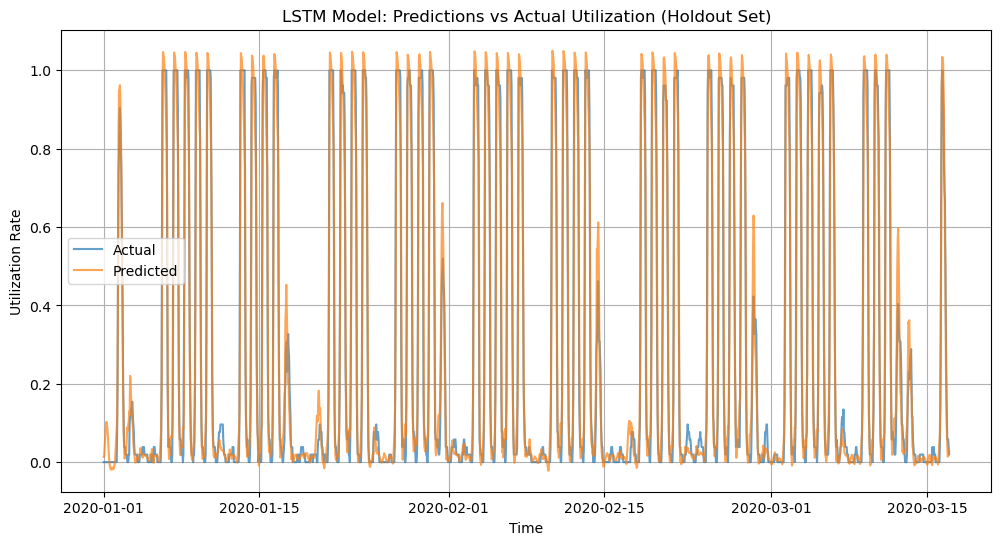

In [308]:
lstm_model_site_1, all_actuals_lstm_site_1, all_predictions_lstm_site_1, holdout_predictions_lstm_site_1 = train_lstm_with_holdout_1(utilization_1_df)

In [309]:
lstm_model_site_1.summary()

Model: "sequential_37"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_62 (LSTM)              (None, 1, 64)             18944     
                                                                 
 lstm_63 (LSTM)              (None, 32)                12416     
                                                                 
 dropout_37 (Dropout)        (None, 32)                0         
                                                                 
 dense_37 (Dense)            (None, 1)                 33        
                                                                 
Total params: 31,393
Trainable params: 31,393
Non-trainable params: 0
_________________________________________________________________


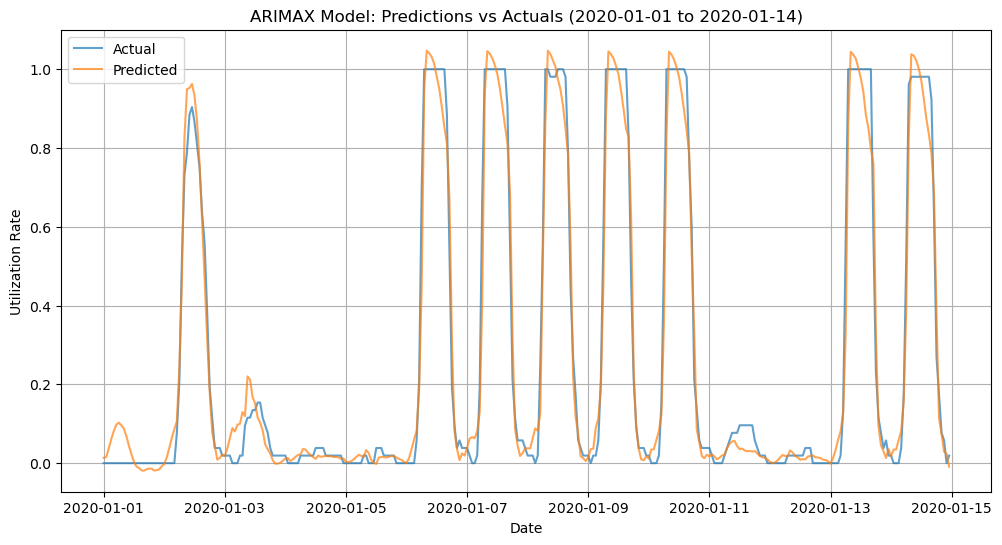

In [311]:
# Define the date range
start_date = "2020-01-01"
end_date = "2020-01-14"

plot_week_predictions(utilization_1_df, holdout_predictions_lstm_site_1, start_date, end_date)

## LSTM Site 2

77/77 [==============================] - 1s 698us/step
Cross-Validation RMSE: 0.0589
Cross-Validation MAE: 0.0440
Cross-Validation R²: 0.9102
57/57 [==============================] - 0s 739us/step
Holdout RMSE: 0.0476
Holdout MAE: 0.0343
Holdout R²: 0.9300


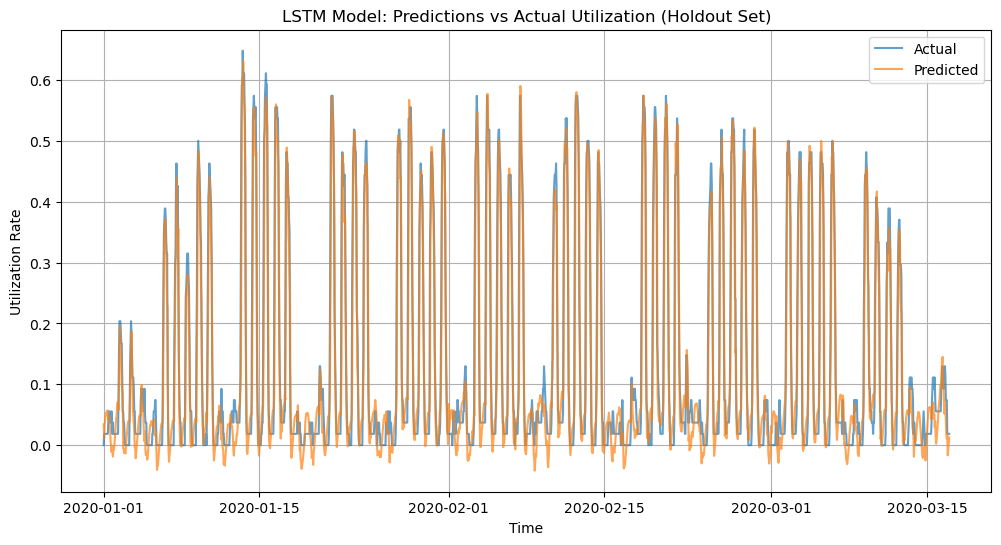

In [312]:
lstm_model_site_2, all_actuals_lstm_site_2, all_predictions_lstm_site_2, holdout_predictions_lstm_site_2 = train_lstm_with_holdout_2(utilization_2_df)

In [313]:
lstm_model_site_2.summary()

Model: "sequential_43"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_74 (LSTM)              (None, 1, 64)             18944     
                                                                 
 lstm_75 (LSTM)              (None, 32)                12416     
                                                                 
 dropout_43 (Dropout)        (None, 32)                0         
                                                                 
 dense_43 (Dense)            (None, 1)                 33        
                                                                 
Total params: 31,393
Trainable params: 31,393
Non-trainable params: 0
_________________________________________________________________


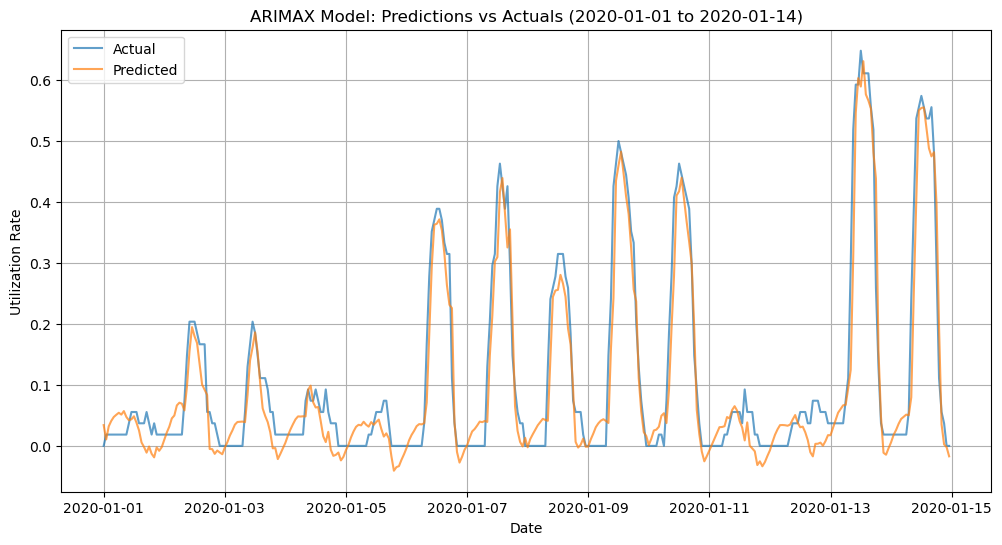

In [314]:
# Define the date range
start_date = "2020-01-01"
end_date = "2020-01-14"

plot_week_predictions(utilization_2_df, holdout_predictions_lstm_site_2, start_date, end_date)

# Holdout Set KPI Comparison ARIMAX vs LSTM

### Site 1

ARIMAX: 
- Holdout RMSE: 0.1018
- Holdout MAE: 0.0721
- Holdout R²: 0.9348

LSTM:
- Holdout RMSE: 0.0636
- Holdout MAE: 0.0435
- Holdout R²: 0.9745

### Site 2

ARIMAX: 
- Holdout RMSE: 0.0482
- Holdout MAE: 0.0348
- Holdout R²: 0.9282

LSTM:
- Holdout RMSE: 0.0476
- Holdout MAE: 0.0343
- Holdout R²: 0.9300

In [ ]:
# TODO 
 
# alter predictions: set all predicitons > 1 to 1 and < 0 to 0 (would improve RMSE and MAE) / downside: currently, predictions > 1 would indicate a higher demand than provided (more charging spaces needed)
# check features: try different features sets in ARIMAX models and check for significance (p value < 0.05)
# hyperparameter tuning (especially for LSTM), for arimax check different settings for order /seasonal_order
# incldue KPI's on train sets to compare train and test KPI's (big differences would indicate overfitting)


start lockdodwn :2020-08-03 22:00:00	
end lockdown: 2020-11-18 11:00:00	